Creating kaggle.json file from Api key

In [2]:
import json

kaggle_credentials = {
    "username": "XAI_Research",
    "key": "KGAT_cbedc248d9946563fc4fdd1519719576"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_credentials, f)

print("kaggle.json created successfully!")

kaggle.json created successfully!


Move the token to the right folder

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Download the dataset

In [5]:
!kaggle datasets download -d victusadi/phishing-urls-dataset-with-extracted-features
!unzip -q phishing-urls-dataset-with-extracted-features.zip
!ls  # see what files got extracted

Dataset URL: https://www.kaggle.com/datasets/victusadi/phishing-urls-dataset-with-extracted-features
License(s): CC0-1.0
phishing-urls-dataset-with-extracted-features.zip: Skipping, found more recently modified local copy (use --force to force download)
replace phishing_features.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n

kaggle.json	       phishing-urls-dataset-with-extracted-features.zip
phishing_features.csv  sample_data


Installing SHAP LIMe  libraries

In [6]:
!pip install shap lime imbalanced-learn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


Verify everything loaded

In [8]:
import pandas as pd
df = pd.read_csv("phishing_features.csv")  # use the filename you saw from !ls
print(df.shape)
print(df.head())

(160064, 13)
                                                 url  label  url_length  \
0  http://forum.uk.securebankinggroup.com/107519/...      1          89   
1                          http://b45042.com/fish/29      1          25   
2                     http://bet73018.com/lottery/99      1          30   
3            https://logiin--metsa-autho.webflow.io/      1          39   
4              https://mettamasklogiiann.webflow.io/      1          37   

   num_dots  has_https  has_ip  num_subdirs  num_params  suspicious_words  \
0         3          0       0            5           0                 2   
1         1          0       0            4           0                 0   
2         1          0       0            4           0                 0   
3         2          1       0            3           0                 0   
4         2          1       0            3           0                 0   

   tld  special_char_count  digits_count   entropy  
0  com              

Data Inspection

In [9]:
print(df.shape)          # rows and columns
print(df.dtypes)         # data types of each column
print(df.isnull().sum()) # check for missing values
print(df.head())

(160064, 13)
url                    object
label                   int64
url_length              int64
num_dots                int64
has_https               int64
has_ip                  int64
num_subdirs             int64
num_params              int64
suspicious_words        int64
tld                    object
special_char_count      int64
digits_count            int64
entropy               float64
dtype: object
url                     0
label                   0
url_length              0
num_dots                0
has_https               0
has_ip                  0
num_subdirs             0
num_params              0
suspicious_words        0
tld                   821
special_char_count      0
digits_count            0
entropy                 0
dtype: int64
                                                 url  label  url_length  \
0  http://forum.uk.securebankinggroup.com/107519/...      1          89   
1                          http://b45042.com/fish/29      1          25   
2      

Check Class Distribution

In [12]:
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True) * 100)

label
1    159244
0       820
Name: count, dtype: int64
label
1    99.487705
0     0.512295
Name: proportion, dtype: float64


Visualize the Imbalance

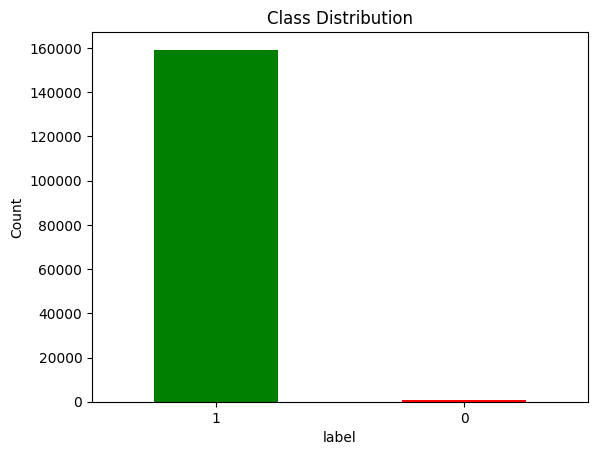

In [14]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Class Distribution')
plt.xlabel('label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

Encode the label column

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])
print(le.classes_)  # see which class got which number

[0 1]


Separate Features and Target

In [21]:
X = df.drop(['label', 'url', 'tld'], axis=1)
y = df['label']

print("Features shape:", X.shape)
print(X.head())

Features shape: (160064, 10)
   url_length  num_dots  has_https  has_ip  num_subdirs  num_params  \
0          89         3          0       0            5           0   
1          25         1          0       0            4           0   
2          30         1          0       0            4           0   
3          39         2          1       0            3           0   
4          37         2          1       0            3           0   

   suspicious_words  special_char_count  digits_count   entropy  
0                 2                   4            29  4.792985  
1                 0                   0             7  4.003856  
2                 0                   0             7  4.053236  
3                 0                   3             0  4.150411  
4                 0                   0             0  4.100817  


Split into Train & Test

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # important! maintains class ratio in both splits
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (128051, 10)
Test size: (32013, 10)


Handle Class Imbalance with SMOTE

In [23]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_bal.value_counts().to_dict())

Before SMOTE: {1: 127395, 0: 656}
After SMOTE: {1: 127395, 0: 127395}


Train Logistic Regression (Baseline)

In [24]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_bal, y_train_bal)
print("Logistic Regression trained!")

Logistic Regression trained!


Train Random Forest (Primary Model)

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)
print("Random Forest trained!")

Random Forest trained!


Make Predictions

In [26]:
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

Evaluate Both Models

In [27]:
from sklearn.metrics import classification_report, roc_auc_score

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       164
           1       1.00      1.00      1.00     31849

    accuracy                           1.00     32013
   macro avg       1.00      1.00      1.00     32013
weighted avg       1.00      1.00      1.00     32013

ROC-AUC: 1.0

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       164
           1       1.00      1.00      1.00     31849

    accuracy                           1.00     32013
   macro avg       1.00      1.00      1.00     32013
weighted avg       1.00      1.00      1.00     32013

ROC-AUC: 1.0


Visualize Confusion Matrices

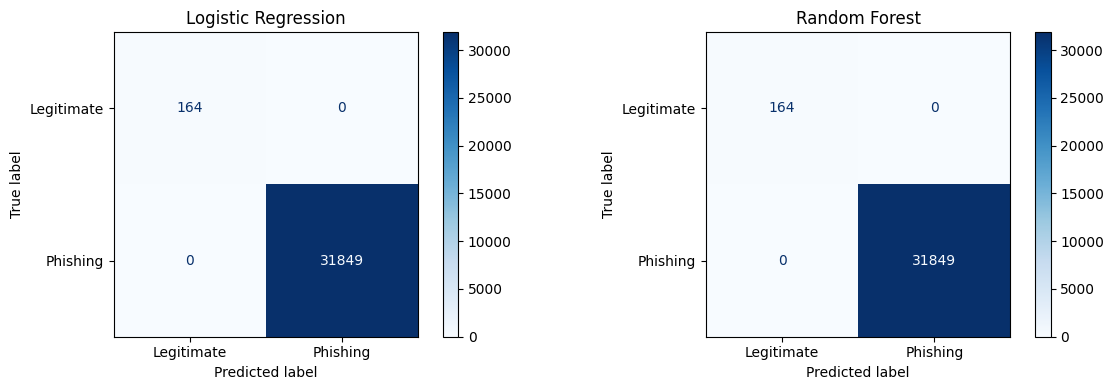

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pred, name in zip(axes,
                           [y_pred_lr, y_pred_rf],
                           ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Phishing'])
    disp.plot(ax=ax, cmap='Blues')
    ax.set_title(name)

plt.tight_layout()
plt.show()

Save Both Models

In [29]:
import joblib

joblib.dump(rf, 'random_forest_model.pkl')
joblib.dump(lr, 'logistic_regression_model.pkl')
print("Models saved!")

Models saved!


SHAP on Random Forest (Global Explanation)

In [30]:
import shap

# Create explainer
explainer_rf = shap.TreeExplainer(rf)

# Use a sample of test data (500 rows) for speed
X_test_sample = X_test.iloc[:500]
shap_values_rf = explainer_rf.shap_values(X_test_sample)
print("SHAP values computed!")

SHAP values computed!


SHAP Summary Plot (Global — which features matter most)

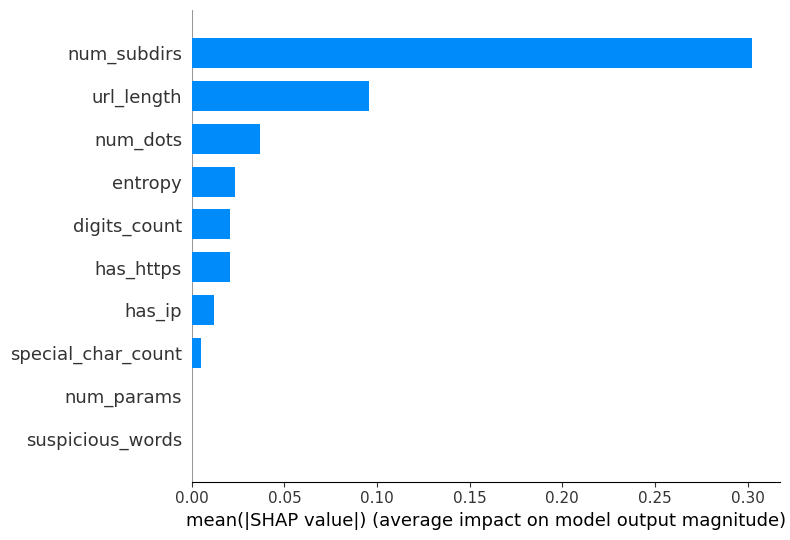

In [31]:
shap.summary_plot(
    shap_values_rf[:,:,1],  # index 1 = phishing class
    X_test_sample,
    plot_type="bar",
    max_display=10
)

SHAP Beeswarm Plot (deeper global view)

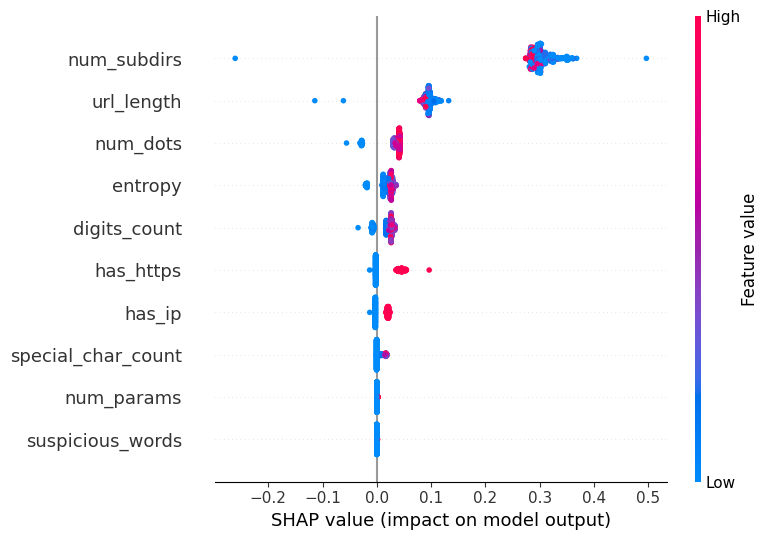

In [32]:
shap.summary_plot(
    shap_values_rf[:,:,1],
    X_test_sample,
    max_display=10
)

SHAP Local Explanation (single prediction)

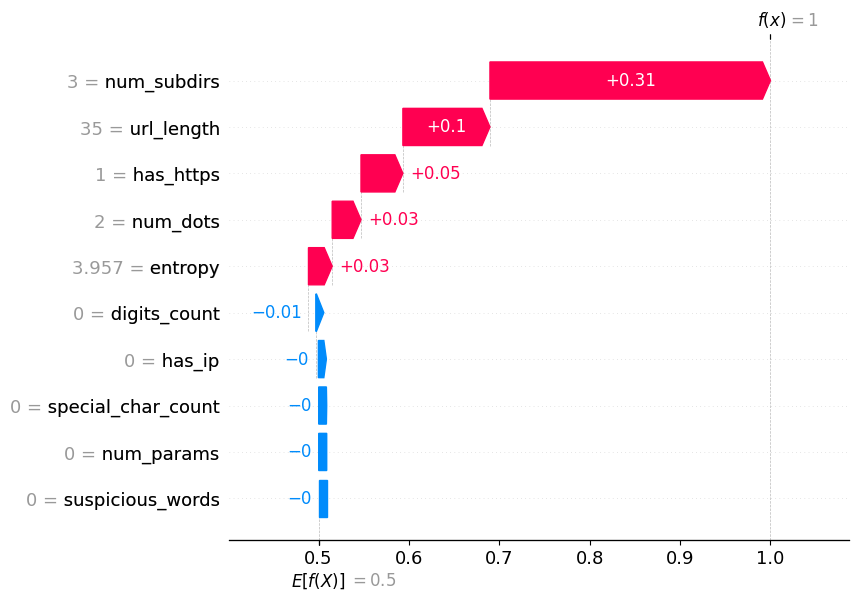

In [34]:
# Pick one phishing URL from test set
idx = 2

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_rf[idx,:,1],
        base_values=explainer_rf.expected_value[1],
        data=X_test_sample.iloc[idx],
        feature_names=X_test_sample.columns.tolist()
    )
)

SHAP on Logistic Regression

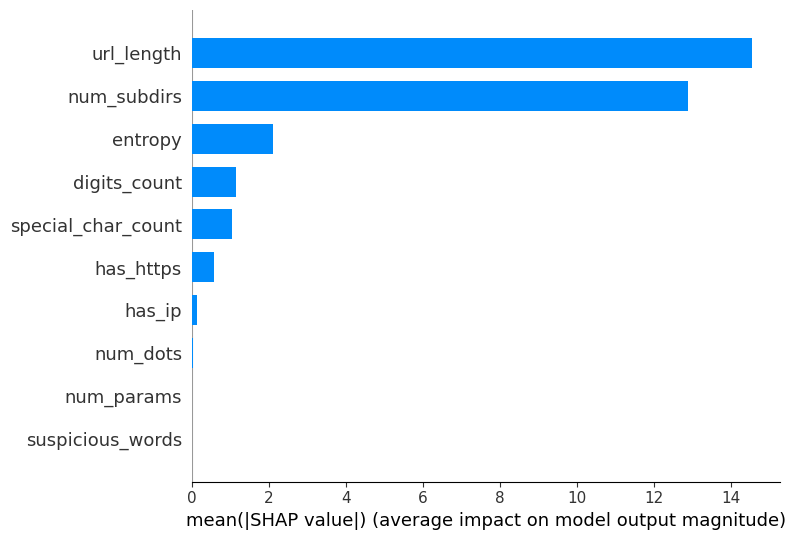

In [36]:
explainer_lr = shap.LinearExplainer(lr, X_train_bal)
shap_values_lr = explainer_lr.shap_values(X_test_sample)

shap.summary_plot(
    shap_values_lr,
    X_test_sample,
    plot_type="bar",
    max_display=10
)

LIME on Random Forest (Local Explanation)

In [37]:
import lime
import lime.lime_tabular

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_bal.values,
    feature_names=X_train_bal.columns.tolist(),
    class_names=['Legitimate', 'Phishing'],
    mode='classification'
)

Explain a single prediction with LIME

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


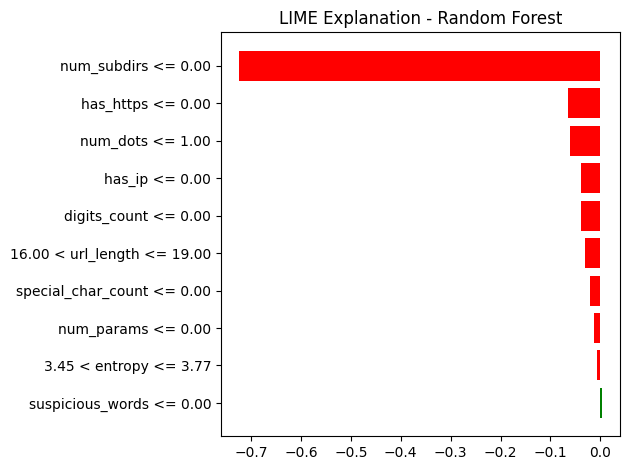

In [38]:
# Explain the same instance we used in SHAP
idx = 0
exp = explainer_lime.explain_instance(
    data_row=X_test_sample.iloc[idx].values,
    predict_fn=rf.predict_proba,
    num_features=10
)

exp.as_pyplot_figure()
plt.title("LIME Explanation - Random Forest")
plt.tight_layout()
plt.show()

LIME on Logistic Regression (for comparison)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


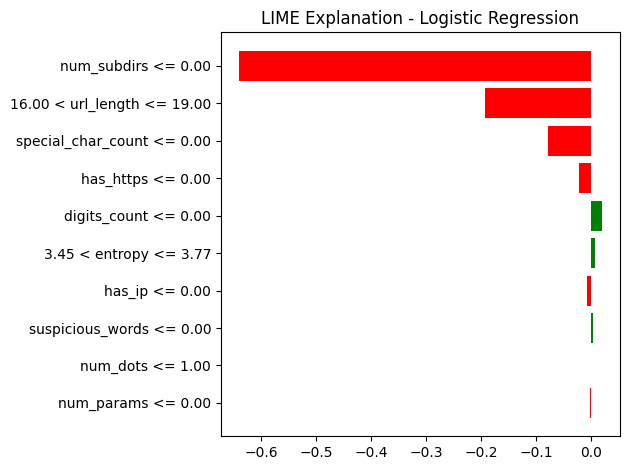

In [39]:
exp_lr = explainer_lime.explain_instance(
    data_row=X_test_sample.iloc[idx].values,
    predict_fn=lr.predict_proba,
    num_features=10
)

exp_lr.as_pyplot_figure()
plt.title("LIME Explanation - Logistic Regression")
plt.tight_layout()
plt.show()

Downlod models for deployment

In [40]:
from google.colab import files
files.download('random_forest_model.pkl')
files.download('logistic_regression_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>